In [1]:
#Importamos paquetes
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm 


from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV

In [2]:
### TRABAJO PRÁCTICO N°4

In [3]:
# Antes de hacer cualquier cosa, corrijamos los errores que tuvimos a la hora de hacer el tp3

In [4]:
# Carguemos entonces la base pero desde el tp3 que ya la habiamos construido mejor.

In [5]:
#os.chdir(r"C:\Users\Gaelj\OneDrive\Documentos\GitHub\E337_Grupo2\TP4")
os.chdir(r"C:\Users\User\Downloads\E337_Grupo2-main\E337_Grupo2-main\TP4")

In [6]:
ocupados = pd.read_csv('ocupados1.csv')

In [7]:
ocupados

,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CH14,CH15_COD,...,PP07H,informal,EMPLEO,edad2,CH12,CH13,educ,ingreso_total_familiar,horastrab,ix_tot
0,1.0,39.0,1.0,4.0,4.0,1.0,0.0,1.391111e+05,NaN,NaN,...,0.0,0,2.0,1521.0,4.0,1.0,12.0,1252000.0,NaN,9
1,1.0,35.0,5.0,1.0,6.0,1.0,0.0,2.500000e+06,NaN,NaN,...,2.0,1,2.0,1225.0,7.0,1.0,17.0,2500000.0,48.0,1
2,2.0,46.0,3.0,1.0,6.0,1.0,0.0,1.133333e+06,NaN,NaN,...,1.0,0,1.0,2116.0,7.0,1.0,17.0,3400000.0,45.0,3
3,1.0,38.0,2.0,1.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,1.0,0,1.0,1444.0,4.0,2.0,105.0,0.0,44.0,10
4,2.0,42.0,2.0,4.0,3.0,1.0,0.0,0.000000e+00,99.0,NaN,...,2.0,1,2.0,1764.0,4.0,2.0,105.0,0.0,NaN,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3877,1.0,53.0,5.0,1.0,2.0,1.0,0.0,3.800000e+02,NaN,NaN,...,1.0,0,NaN,2809.0,2.0,1.0,6.0,1081905.6,NaN,3
3878,1.0,52.0,2.0,4.0,2.0,1.0,0.0,1.533333e+02,NaN,NaN,...,2.0,1,NaN,2704.0,2.0,1.0,6.0,436558.4,114.0,3
3879,2.0,38.0,3.0,12.0,6.0,1.0,0.0,2.500000e+02,NaN,NaN,...,1.0,0,NaN,1444.0,6.0,1.0,15.0,474520.0,49.0,2
3880,1.0,28.0,2.0,4.0,2.0,1.0,0.0,1.250000e+02,NaN,NaN,...,0.0,0,NaN,784.0,2.0,1.0,6.0,711780.0,4.0,6


In [8]:
# Ahora bien, para la construcción de la variable X nos habian pedido no solo con las variables que habiamos creado
# sino que era de manera general. Para ello debiamos seleccionar al menos 15 de ellas y justificar porque creiamos que podrian serlo

In [9]:
# Que Y sea la variable informal estaba bien, en eso no habia problemas. Pensemos ahora mirando el dicionario
# cuales nos pueden servir para la matriz X.

In [10]:
ocupados.columns

Index(['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC',
       'IPCF', 'CH14', 'CH15_COD', 'CH16_COD', 'PP03C', 'PP04B_COD', 'PP06H',
       'PP07A', 'AÑO', 'CAT_OCUP', 'PP07H', 'informal', 'EMPLEO', 'edad2',
       'CH12', 'CH13', 'educ', 'ingreso_total_familiar', 'horastrab',
       'ix_tot'],
      dtype='object')

In [11]:
# Primero, como determinante de la informalidad podemos a tener la edad dado a que para ciertas edades resulta más díficil la obtención
# de ciertos empleos. Lo que es edad2 podría estar capturando la relación no lineal entre edad e informalidad. Educ también puede ser 
# una variable que podemos considerar, dado a en muchos casos es lo que determina las posibilidades de trabajo que pueden tener los 
# individuos. Respecto a los ingresos totales familiares, los ingresos bajos podrían estar correlacionados justamente con informalidad.

# Ix_tot por otro lado, te indica la cantidad total de los integrantes de la familia, por lo que uno podría pensar que hogares más numerosos 
# estarían más presionados a aceptar trabajos más informales. Con horastrab podemos ver horarios de trabajos muy bajos o extremadamentes altos
# que podrían estar explicados por ser trabajos informales. CH04 porque podría haber una tendencia mayor en obtención de empleos informales de un
# lado u otro. PP07H nos indica la antiguedad en el trabajo por lo que también puede ser algo que nos explique la informalidad o no.

# PP03C indica la cantidad de ocupaciones que tiene la persona por lo que podemos pensar que entre más trabajos tenga más intenta compensar 
# agarrando más empleos informales. En el caso de CAT_OCUP nos indica la categoría ocupacional que tiene, diciendonos el tipo de relación laboral
# que tiene la persona. Por último, CH07 nos indica el estado civil de la persona, cosa que nos ayudaría a ver si hay una tendencia respecto a la 
# gente casada busca o no empleos más formales. 

In [12]:
# Guardemos en una lista justamente estas variables que vamos a usar

var_x = ['CH06', 'edad2', 'educ', 'ingreso_total_familiar', 'ix_tot', 'horastrab','CH04', 'PP07H', 'PP03C','CAT_OCUP', 'CH07']

In [13]:
# Hay que tener ciudado porque algunas de esas variables que elegimos son categoricas

vars_continuas = ['CH06', 'edad2', 'educ', 'ingreso_total_familiar', 
                  'ix_tot', 'horastrab']

vars_binarias = ['CH04', 'PP07H', 'PP03C']  # recodificar a 0/1

vars_dummies = ['CAT_OCUP', 'CH07']  # get_dummies

In [14]:
# Filtrar solamente las observaciones de 2025
ocupados_2025 = ocupados[ocupados['AÑO'] == 2025].copy()

# Crear la matriz X con solo esas variables
X_2025 = ocupados_2025[var_x].copy()

In [15]:
# Lo mismo vamos a hacer para 2005

# Filtrar solamente las observaciones de 2025
ocupados_2005 = ocupados[ocupados['AÑO'] == 2005].copy()

# Crear la matriz X con solo esas variables
X_2005 = ocupados_2005[var_x].copy()

In [16]:
# Ahora, guardemos también por separado la variable dependiente y:

y_2025 = ocupados_2025['informal'].copy()
y_2005= ocupados_2005['informal'].copy()

In [17]:
for v in vars_binarias:
    ocupados_2025[v] = (ocupados_2025[v] == 1).astype(int)

In [18]:
df_dummies = pd.get_dummies(ocupados_2025[vars_dummies], drop_first=True)

In [19]:
# X completa
X_2025 = pd.concat([ocupados_2025[vars_continuas + vars_binarias], df_dummies], axis=1)

# Eliminar filas con NAs
mask = X_2025.notna().all(axis=1) & y_2025.notna()
X_2025 = X_2025[mask]
y_2025 = y_2025[mask]

In [20]:
# Lo mismo para 2005:
for v in vars_binarias:
    ocupados_2005[v] = (ocupados_2005[v] == 1).astype(int)

df_dummies = pd.get_dummies(ocupados_2005[vars_dummies], drop_first=True)

# X completa
X_2005 = pd.concat([ocupados_2005[vars_continuas + vars_binarias], df_dummies], axis=1)

# Eliminar filas con NAs
mask = X_2005.notna().all(axis=1) & y_2005.notna()
X_2005 = X_2005[mask]
y_2005 = y_2005[mask]

In [21]:
# Con esto, deberíamos poder divir las muestras entre train y test con la función dada

X2025_train, X2025_test, y2025_train, y2025_test = train_test_split(X_2025, y_2025, test_size=0.30, random_state=444)

X2005_train, X2005_test, y2005_train, y2005_test = train_test_split(X_2005, y_2005, test_size=0.30, random_state=444)

In [22]:
# Ya con esto podriamos hacer bien el tp4

In [23]:
### A. Modelo de Regresión Logística con Regularización: Ridge y LASSO

In [24]:
### 1) 

In [25]:
# Realizemos el gráfico, pero para ello necesitamos armar las distintas penalidades que nos dieron:

In [26]:
n = [-5,-4,-3,-2,-1,0,1,2,3,4,5]
alphas = []

for n_val in n:
    alphas.append(10**n_val)

print(alphas)

[1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]


In [27]:
# Para poder realizar la regresión logistica:

# En LogisticRegression C = 1/lambda
Cs = []

for alpha in alphas:
    Cs.append(1/alpha)

In [28]:
# Nos faltaria estandarizar los valroes:

In [29]:
# Iniciamos el Standard Scaler
sc_2025 = StandardScaler()

# La estandarización únicamente es con variables númericas, por lo que solamente lo vamos a hacer con ellas

numericas = ['CH06', 'edad2', 'educ', 'ingreso_total_familiar', 'ix_tot', 'horastrab']

# Estandarizamos las observaciones de entrenamiento
X2025_train[numericas] = sc_2025.fit_transform(X2025_train[numericas])

In [30]:
# Hagamos lo mismo para 2005
sc_2005 = StandardScaler()

numericas = ['CH06', 'edad2', 'educ', 'ingreso_total_familiar', 'ix_tot', 'horastrab']

# Estandarizamos las observaciones de entrenamiento
X2005_train[numericas] = sc_2005.fit_transform(X2005_train[numericas])

In [31]:
# Empecemos con Ridge:

ridge_2025 = []

for C in Cs:
    model = LogisticRegression(penalty='l2', C=C, fit_intercept=False,
                                solver='lbfgs', max_iter=1000)
    model.fit(X2025_train, y2025_train)
    ridge_2025.append(pd.Series(model.coef_[0], index=X2025_train.columns))

In [32]:
# Ahora hagamos lo mismo para LASSO:

LASSO_2025 = []

for C in Cs:
    model = LogisticRegression(penalty='l1', C=C, fit_intercept=False,
                                solver='liblinear', max_iter=1000)
    model.fit(X2025_train, y2025_train)
    LASSO_2025.append(pd.Series(model.coef_[0], index=X2025_train.columns))

In [33]:
# --- GRÁFICOS ---
df_ridge2025 = pd.DataFrame(ridge_2025, index=n)
df_lasso2025 = pd.DataFrame(LASSO_2025, index=n)

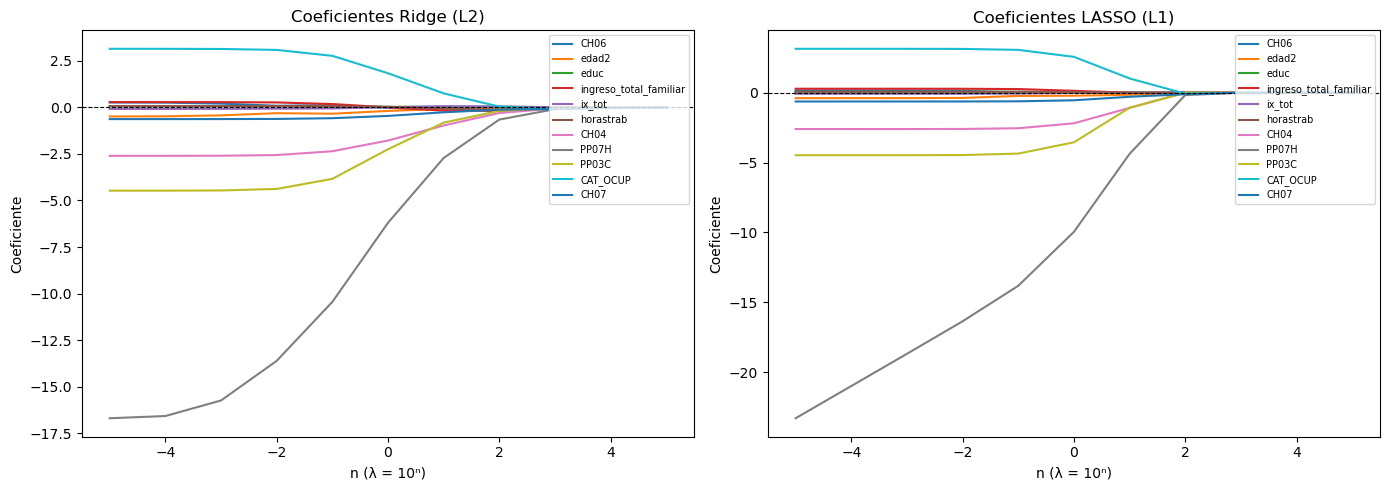

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col in df_ridge2025.columns:
    axes[0].plot(n, df_ridge2025[col], label=col)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coeficientes Ridge (L2)')
axes[0].set_xlabel('n (λ = 10ⁿ)')
axes[0].set_ylabel('Coeficiente')
axes[0].legend(fontsize=7, loc='upper right')

for col in df_lasso2025.columns:
    axes[1].plot(n, df_lasso2025[col], label=col)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Coeficientes LASSO (L1)')
axes[1].set_xlabel('n (λ = 10ⁿ)')
axes[1].set_ylabel('Coeficiente')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig("coeficientes_ridge_lasso2025.png", dpi=300)
plt.show()

In [35]:
# Para este caso de 2025, podemos apreciar que para los dos métodos / técnicas de regularización que, a medida de que aumenta el parámetro de 
# penalización los coeficientes empiezan a disminuir con respecto al comparativo que sería el de MCO. En el caso de Ridge, los coeficientes cuando 
# la penalidad tiende a infinito, estos van a tender a 0 pero nunca serlos. Mientras que para LASSO si pueden ser 0, siendo más 
# un proceso selectivo de las variables. 

In [36]:
# Hagamos de vuelta lo mismo para 2005:

ridge_2005 = []

for C in Cs:
    model = LogisticRegression(penalty='l2', C=C, fit_intercept=False,
                                solver='lbfgs', max_iter=1000)
    model.fit(X2005_train, y2005_train)
    ridge_2005.append(pd.Series(model.coef_[0], index=X2005_train.columns))

LASSO_2005 = []

for C in Cs:
    model = LogisticRegression(penalty='l1', C=C, fit_intercept=False,
                                solver='liblinear', max_iter=1000)
    model.fit(X2005_train, y2005_train)
    LASSO_2005.append(pd.Series(model.coef_[0], index=X2005_train.columns))

In [37]:
# --- GRÁFICOS ---
df_ridge2005 = pd.DataFrame(ridge_2005, index=n)
df_lasso2005 = pd.DataFrame(LASSO_2005, index=n)

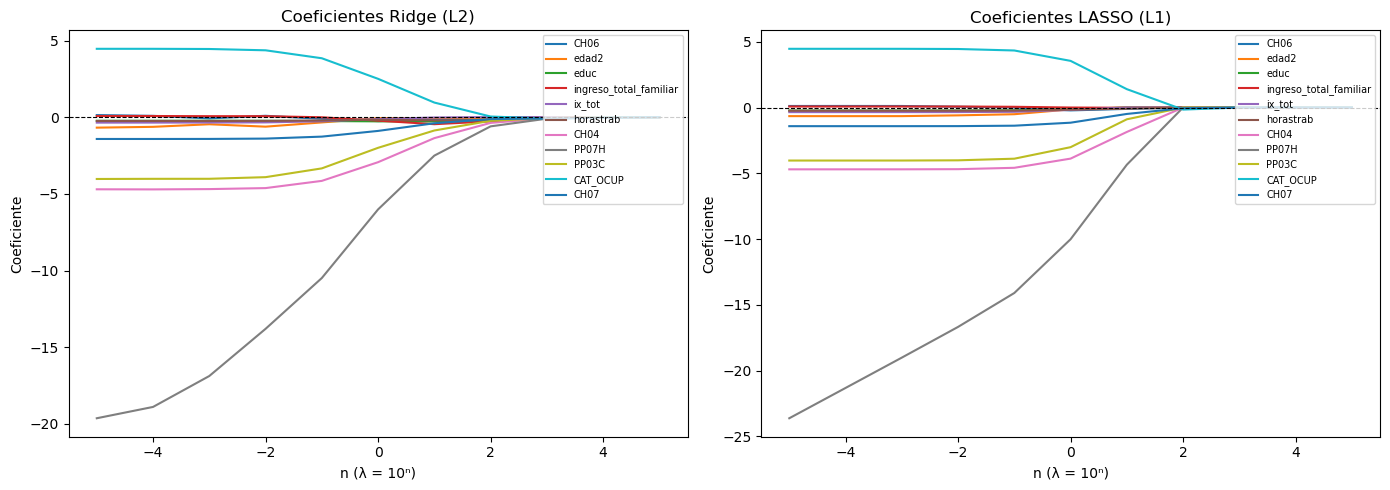

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col in df_ridge2005.columns:
    axes[0].plot(n, df_ridge2005[col], label=col)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Coeficientes Ridge (L2)')
axes[0].set_xlabel('n (λ = 10ⁿ)')
axes[0].set_ylabel('Coeficiente')
axes[0].legend(fontsize=7, loc='upper right')

for col in df_lasso2005.columns:
    axes[1].plot(n, df_lasso2005[col], label=col)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Coeficientes LASSO (L1)')
axes[1].set_xlabel('n (λ = 10ⁿ)')
axes[1].set_ylabel('Coeficiente')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig("coeficientes_ridge_lasso2005.png", dpi=300)
plt.show()

In [39]:
# Justamente para 2005 pasa lo mismo para los dos métodos, en Ridge tienen a 0 los coeficientes con penalidades muy altas 
# mientras que en el caso de LASSO si terminan siendo algunos 0 sus coeficientes. De igual manera como en el gráfico anterior, 
# algunos coeficientes como que ocilan siempre entre 0 sin importar la pensalidad, por lo que no parecerían relevantes. 

In [40]:
### 2)

In [41]:
# Realizemos lo pedido en este ejercicio.  

In [42]:
# Para 2025:

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

# --- RIDGE por CV ---
ridge2025_cv = LogisticRegressionCV(Cs=Cs, penalty='l2',cv=cv5,fit_intercept=False,solver='lbfgs',max_iter=1000,scoring='accuracy')
ridge2025_cv.fit(X2025_train, y2025_train)

lambda_opt_ridge2025 = 1 / ridge2025_cv.C_[0]
print(f"λ óptimo Ridge: {lambda_opt_ridge2025:.5f}  (C = {ridge2025_cv.C_[0]:.5f})")

λ óptimo Ridge: 0.10000  (C = 10.00000)


In [43]:
# --- LASSO por CV ---
lasso2025_cv = LogisticRegressionCV(Cs=Cs,penalty='l1',cv=cv5,fit_intercept=False,solver='liblinear',max_iter=1000,scoring='accuracy')
lasso2025_cv.fit(X2025_train, y2025_train)

lambda_opt_lasso2025 = 1 / lasso2025_cv.C_[0]
print(f"λ óptimo LASSO: {lambda_opt_lasso2025:.5f}  (C = {lasso2025_cv.C_[0]:.5f})")

λ óptimo LASSO: 1.00000  (C = 1.00000)


In [44]:
# Hagamos lo mismo para 2005:

# --- RIDGE por CV ---
ridge2005_cv = LogisticRegressionCV(Cs=Cs, penalty='l2',cv=cv5,fit_intercept=False,solver='lbfgs',max_iter=1000,scoring='accuracy')
ridge2005_cv.fit(X2005_train, y2005_train)

lambda_opt_ridge2005 = 1 / ridge2005_cv.C_[0]
print(f"λ óptimo Ridge: {lambda_opt_ridge2005:.5f}  (C = {ridge2005_cv.C_[0]:.5f})")

# --- LASSO por CV ---
lasso2005_cv = LogisticRegressionCV(Cs=Cs,penalty='l1',cv=cv5,fit_intercept=False,solver='liblinear',max_iter=1000,scoring='accuracy')
lasso2005_cv.fit(X2005_train, y2005_train)

lambda_opt_lasso2005 = 1 / lasso2005_cv.C_[0]
print(f"λ óptimo LASSO: {lambda_opt_lasso2005:.5f}  (C = {lasso2005_cv.C_[0]:.5f})")

λ óptimo Ridge: 1.00000  (C = 1.00000)
λ óptimo LASSO: 1.00000  (C = 1.00000)


In [45]:
# Realizemos los boxplots:

In [46]:
# =========================
# BOXPLOTS RIDGE Y LASSO
# =========================

# Errores Ridge
ridge_errors2025 = 1 - ridge2025_cv.scores_[1]

# Errores LASSO
lasso_errors2025 = 1 - lasso2025_cv.scores_[1]

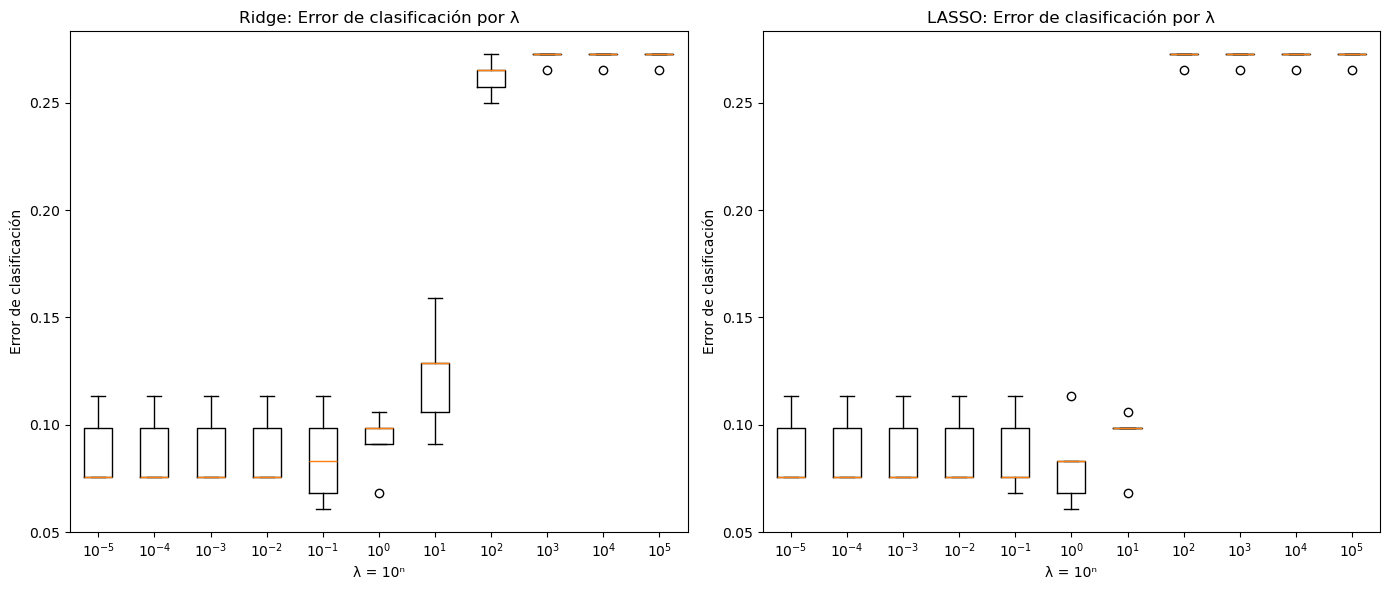

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# RIDGE
axes[0].boxplot(
    ridge_errors2025,
    tick_labels=[f"$10^{{{i}}}$" for i in n]
)

axes[0].set_title("Ridge: Error de clasificación por λ")
axes[0].set_xlabel("λ = 10ⁿ")
axes[0].set_ylabel("Error de clasificación")


# LASSO
axes[1].boxplot(
    lasso_errors2025,
    tick_labels=[f"$10^{{{i}}}$" for i in n]
)

axes[1].set_title("LASSO: Error de clasificación por λ")
axes[1].set_xlabel("λ = 10ⁿ")
axes[1].set_ylabel("Error de clasificación")

plt.tight_layout()
plt.savefig("boxplots2025.png", dpi=300)
plt.show()

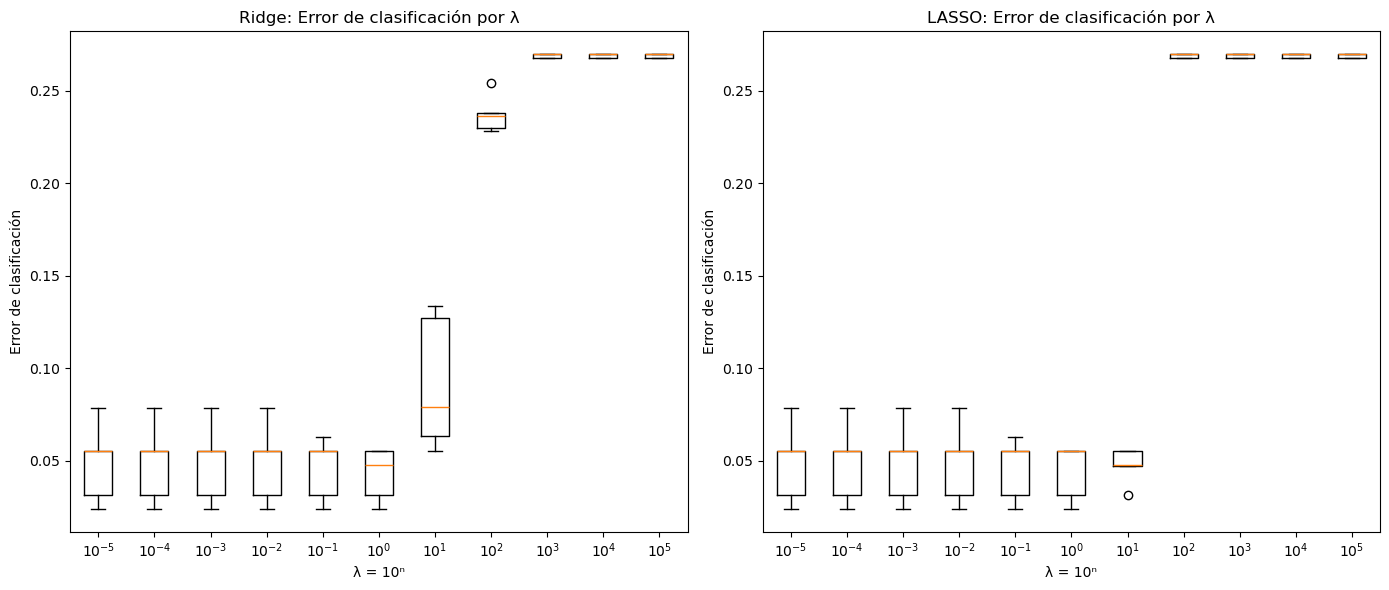

In [48]:
# Ahora para 2005:

# Errores Ridge
ridge_errors2005 = 1 - ridge2005_cv.scores_[1]

# Errores LASSO
lasso_errors2005 = 1 - lasso2005_cv.scores_[1]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# RIDGE
axes[0].boxplot(
    ridge_errors2005,
    tick_labels=[f"$10^{{{i}}}$" for i in n]
)

axes[0].set_title("Ridge: Error de clasificación por λ")
axes[0].set_xlabel("λ = 10ⁿ")
axes[0].set_ylabel("Error de clasificación")


# LASSO
axes[1].boxplot(
    lasso_errors2005,
    tick_labels=[f"$10^{{{i}}}$" for i in n]
)

axes[1].set_title("LASSO: Error de clasificación por λ")
axes[1].set_xlabel("λ = 10ⁿ")
axes[1].set_ylabel("Error de clasificación")

plt.tight_layout()
plt.savefig("boxplots2005.png", dpi=300)
plt.show()

In [49]:
### 3) Estimación con λ_cv y comparación de coeficientes

In [50]:
# ============================================================
# ÍTEM 3: Logit sin penalidad, con L1 y L2 usando λ óptimo
# Usamos únicamente la base de 2025, sin intercepto
# ============================================================

# --- Modelo 1: Logit SIN penalidad ---
logit_sin_pen = LogisticRegression(
    penalty=None,           # sin regularización
    fit_intercept=False,    # sin intercepto, como pide la consigna
    solver='lbfgs',
    max_iter=1000
)
logit_sin_pen.fit(X2025_train, y2025_train)

# --- Modelo 2: Logit con L1 (LASSO) y λ_cv óptimo ---
# Recordá: en sklearn C = 1/λ
C_optimo_lasso = 1 / lambda_opt_lasso2025

logit_L1 = LogisticRegression(
    penalty='l1',
    C=C_optimo_lasso,
    fit_intercept=False,
    solver='liblinear',
    max_iter=1000
)
logit_L1.fit(X2025_train, y2025_train)

# --- Modelo 3: Logit con L2 (Ridge) y λ_cv óptimo ---
C_optimo_ridge = 1 / lambda_opt_ridge2025

logit_L2 = LogisticRegression(
    penalty='l2',
    C=C_optimo_ridge,
    fit_intercept=False,
    solver='lbfgs',
    max_iter=1000
)
logit_L2.fit(X2025_train, y2025_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(10.0)
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [51]:
# ============================================================
# Armamos la tabla comparativa de coeficientes
# ============================================================

tabla_coefs = pd.DataFrame({
    'Sin penalidad': logit_sin_pen.coef_[0],
    f'L1 (λ={lambda_opt_lasso2025:.4f})': logit_L1.coef_[0],
    f'L2 (λ={lambda_opt_ridge2025:.4f})': logit_L2.coef_[0]
}, index=X2025_train.columns)

# Redondeamos para que se vea prolija
tabla_coefs = tabla_coefs.round(4)

print("=== Tabla comparativa de coeficientes ===")
print(tabla_coefs.to_string())

=== Tabla comparativa de coeficientes ===
                        Sin penalidad  L1 (λ=1.0000)  L2 (λ=0.1000)
CH06                           0.2618         0.0000         0.1169
edad2                         -0.4900        -0.2162        -0.3415
educ                           0.0598         0.0309         0.0468
ingreso_total_familiar         0.2817         0.1343         0.1768
ix_tot                        -0.0850        -0.0142        -0.0577
horastrab                      0.0651         0.0420         0.0600
CH04                          -2.6044        -2.1902        -2.3571
PP07H                        -16.7062        -9.9584       -10.4440
PP03C                         -4.4747        -3.5507        -3.8380
CAT_OCUP                       3.1424         2.5638         2.7645
CH07                          -0.6315        -0.5437        -0.5829


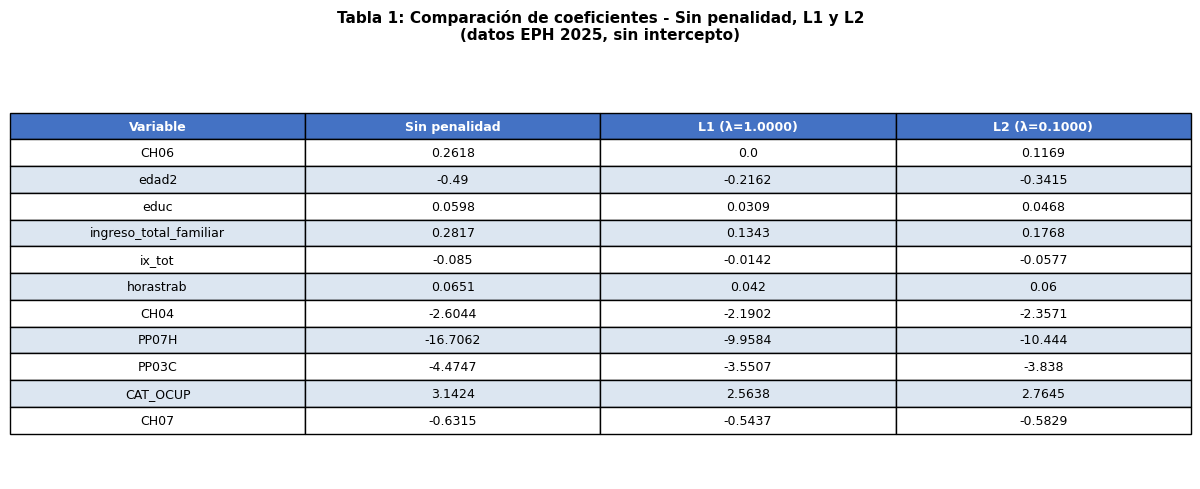

In [52]:
# ============================================================
# Exportamos la tabla como imagen para el informe
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

tabla_display = tabla_coefs.reset_index()
tabla_display.columns = ['Variable'] + list(tabla_coefs.columns)

table = ax.table(
    cellText=tabla_display.values,
    colLabels=tabla_display.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Colorear encabezados
for j in range(len(tabla_display.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Colorear filas alternas para legibilidad
for i in range(1, len(tabla_display) + 1):
    for j in range(len(tabla_display.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#DCE6F1')

plt.title('Tabla 1: Comparación de coeficientes - Sin penalidad, L1 y L2\n(datos EPH 2025, sin intercepto)', 
          fontsize=11, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("tabla_coeficientes_item3.png", dpi=300, bbox_inches='tight')
plt.show()

In [53]:
# ============================================================
# Identificar variables que L1 elimina (coef = 0)
# ============================================================

vars_eliminadas_L1 = tabla_coefs[tabla_coefs[f'L1 (λ={lambda_opt_lasso2025:.4f})'] == 0].index.tolist()

print(f"\nVariables con coeficiente = 0 en L1 (LASSO): {len(vars_eliminadas_L1)}")
if vars_eliminadas_L1:
    for v in vars_eliminadas_L1:
        print(f"  - {v}")
else:
    print("  Ninguna variable fue eliminada completamente.")

print(f"\nVariables con coeficiente = 0 en L2 (Ridge): ", end="")
vars_eliminadas_L2 = tabla_coefs[tabla_coefs[f'L2 (λ={lambda_opt_ridge2025:.4f})'] == 0].index.tolist()
print(len(vars_eliminadas_L2))


Variables con coeficiente = 0 en L1 (LASSO): 1
  - CH06

Variables con coeficiente = 0 en L2 (Ridge): 0
